深层网络
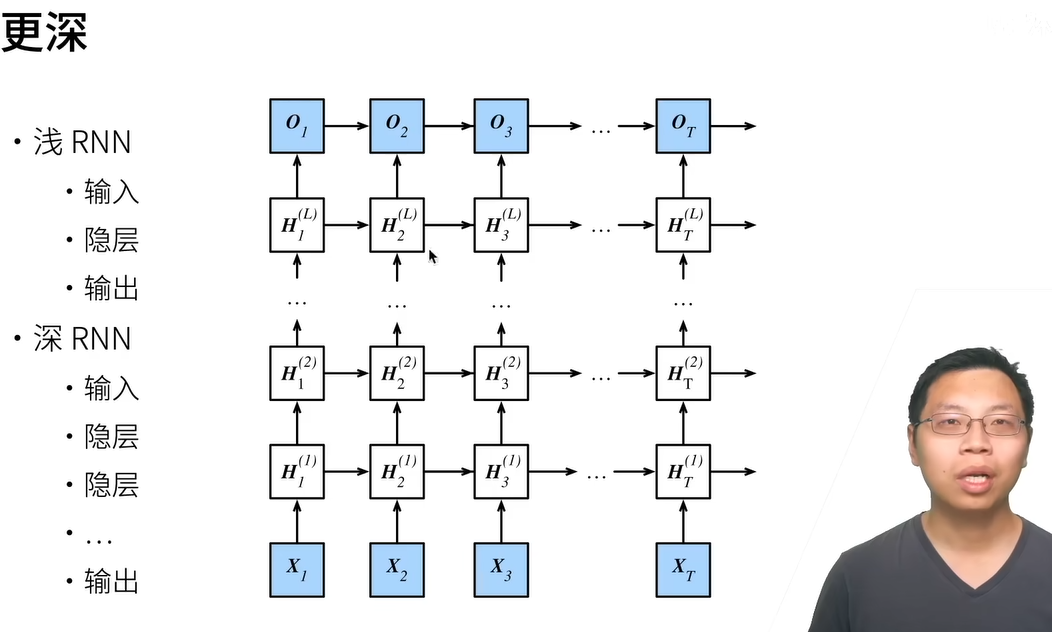

每一个隐藏状态的输入由同时间步的上一层的隐藏状态的输出和同一层的上个时间步的隐藏状态的输出组合得到

目的：获得更深程度的非线性

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 定义数据的维度参数
batch_size = 2   # 一次输入 2 条序列
seq_len = 5      # 序列长度为 5（即时间步 t = 1, 2, 3, 4, 5）
input_size = 10  # 每个时间步输入的特征维度是 10
hidden_size = 16 # 隐状态 h 的特征维度是 16
num_layers = 3   # 堆叠 3 层 RNN（深层网络）

# 随机生成一个输入张量 X
x = torch.randn(batch_size, seq_len, input_size)

print("x 的形状是:", x.shape)

x 的形状是: torch.Size([2, 5, 10])


In [14]:
class PyTorchDeepRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        
        # 定义多层 RNN 核心层
        # batch_first=True 表示输入为 (batch, seq, feature)
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            nonlinearity='tanh',  # 激活函数默认为 tanh
            batch_first=True
        )
        
        # 最后的线性分类/回归头
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, h0=None):
        # 1. 如果没有传入初始隐藏状态 h0，全零初始化
        if h0 is None:
            # h0 维度必须是: (num_layers, batch_size, hidden_size)
            batch_size = x.size(0)
            h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=x.device)
            
        # 2. 通过 RNN 层前向传播
        # rnn_out: 所有时间步最后一层的输出
        # hn: 最后一个时间步所有 3 层的隐状态
        rnn_out, hn = self.rnn(x, h0)
        
        # 3. 假设我们做分类任务，只取最后一个时间步 (last step) 的输出
        last_step_out = rnn_out[:, -1, :] # 形状: (batch_size, hidden_size)
        out = self.fc(last_step_out)      # 形状: (batch_size, output_size)
        
        return out, rnn_out, hn

In [15]:
output_size = 2
model_official = PyTorchDeepRNN(input_size,hidden_size,num_layers,output_size)

out,rnn_out,hn = model_official(x)

print("--- 官方 API 输出维度 ---")
print("1. 全序列最后一层输出 rnn_out shape:", rnn_out.shape)
print("2. 最后时刻全层隐状态 hn shape:      ", hn.shape)
print("3. 分类/预测层最终输出 out shape:   ", out.shape)

--- 官方 API 输出维度 ---
1. 全序列最后一层输出 rnn_out shape: torch.Size([2, 5, 16])
2. 最后时刻全层隐状态 hn shape:       torch.Size([3, 2, 16])
3. 分类/预测层最终输出 out shape:    torch.Size([2, 2])


In [20]:
class SingleRNNCell(nn.Module):
    def __init__(self,input_size,hidden_size):
        super().__init__()
        self.W_ih = nn.Parameter(torch.randn(hidden_size,input_size)*0.1)
        self.b_ih = nn.Parameter(torch.zeros(hidden_size))

        self.W_hh = nn.Parameter(torch.randn(hidden_size,hidden_size)*0.1)
        self.b_hh = nn.Parameter(torch.zeros(hidden_size))

    def forward(self,x_t,h_prev):
        gate_input = x_t @self.W_ih.T +self.b_ih
        gate_hidden = h_prev @ self.W_hh.T+self.b_hh
        h_t = torch.tanh(gate_input+gate_hidden)

        return h_t

In [21]:
class CustomDeepRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        
        # 1. 组装大楼：用 nn.ModuleList 装下每一层的 SingleRNNCell
        self.cells = nn.ModuleList()
        for l in range(num_layers):
            # 第一层的输入是 input_size，以上层的输入都是 hidden_size
            layer_input_size = input_size if l == 0 else hidden_size
            self.cells.append(SingleRNNCell(layer_input_size, hidden_size))

    def forward(self, x):
        batch_size = x.shape[0]
        seq_len = x.shape[1]
        
        # 2. 初始化每一层的记忆（一共有 num_layers 份记忆，全是全零）
        h_states = [torch.zeros(batch_size, self.hidden_size, device=x.device) 
                    for _ in range(self.num_layers)]
        
        layer_outputs = [] # 用来保存每个时刻【顶层】的输出
        
        # 3. 你刚刚推导出的双重循环！
        for t in range(seq_len):
            x_t = x[:, t, :]
            
            for l in range(self.num_layers):
                # 你的杰作：楼层输入判断
                in_feat = x_t if l == 0 else h_states[l-1]
                
                # 调用当前层的细胞，更新当前层的记忆
                h_states[l] = self.cells[l](in_feat, h_states[l])
                
            # 我们通常只收集“最高层”每一秒的输出
            layer_outputs.append(h_states[-1].unsqueeze(1))
            
        # 把最高层的输出在时间维度上拼起来
        rnn_out = torch.cat(layer_outputs, dim=1)
        # 把最后时刻所有层的记忆拼起来
        hn = torch.stack(h_states, dim=0)
        
        return rnn_out, hn

# -------- 测试一下你手搓的模型 --------
# 生成一点伪数据
x = torch.randn(2, 5, 10)  # (batch=2, seq_len=5, input=10)

# 实例化你的模型 (3层深层网络)
my_model = CustomDeepRNN(input_size=10, hidden_size=16, num_layers=3)
my_rnn_out, my_hn = my_model(x)

print("太棒了！你的手搓深层 RNN 跑通了：")
print("输出特征 rnn_out 的维度:", my_rnn_out.shape) 
print("最终隐状态 hn 的维度:  ", my_hn.shape)

太棒了！你的手搓深层 RNN 跑通了：
输出特征 rnn_out 的维度: torch.Size([2, 5, 16])
最终隐状态 hn 的维度:   torch.Size([3, 2, 16])
